In [1]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Section 2 — Load & Explore the Data

In [3]:
from sklearn.datasets import load_iris

# Load the built-in iris dataset from sklearn
iris_raw = load_iris()

# Convert to pandas DataFrame with proper column names
df = pd.DataFrame(
    data=iris_raw.data,
    columns=iris_raw.feature_names
)

# Add species as a numeric column (0, 1, 2)
df['species'] = iris_raw.target

# Map numbers to actual species names for readability
df['species_name'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✅ Dataset loaded!
Rows: 150, Columns: 6


In [4]:
# Display first 5 rows of the dataset
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
# Display last 5 rows to confirm all species are present
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [6]:
# Number of rows and columns
print("Shape:", df.shape)

# Column names, data types, and non-null counts
df.info()

Shape: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Count missing values in each column
print("Missing values:\n", df.isnull().sum())

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [8]:
# Shows count, mean, std, min, max for each numeric column
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [9]:
# How many flowers exist per species?
print(df['species_name'].value_counts())

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Section 3 — Data Visualization (EDA Charts)
We will plot 4 types of charts, one by one. Each chart tells you something different about the data.

In [10]:
# Set the visual theme for all plots
sns.set_style("whitegrid")

# Set default figure size for all plots
plt.rcParams['figure.figsize'] = (8, 5)

print("✅ Plot style set!")

✅ Plot style set!


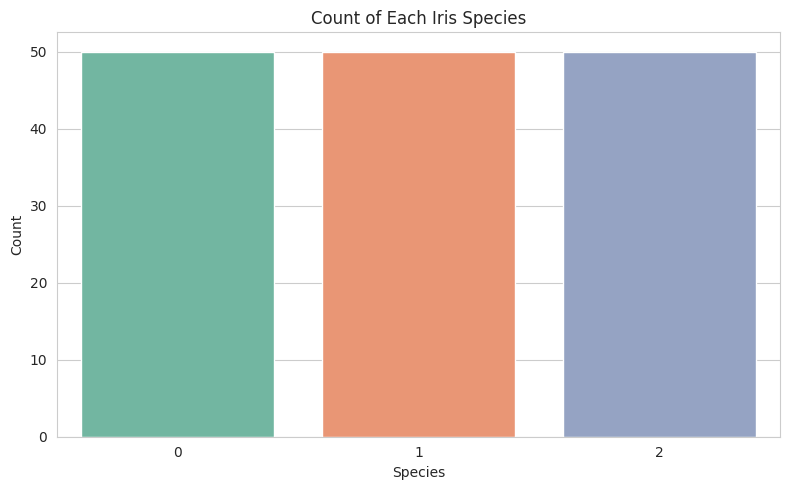

In [11]:
sns.countplot(x='species', data=df, palette='Set2', hue='species', legend=False)

plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

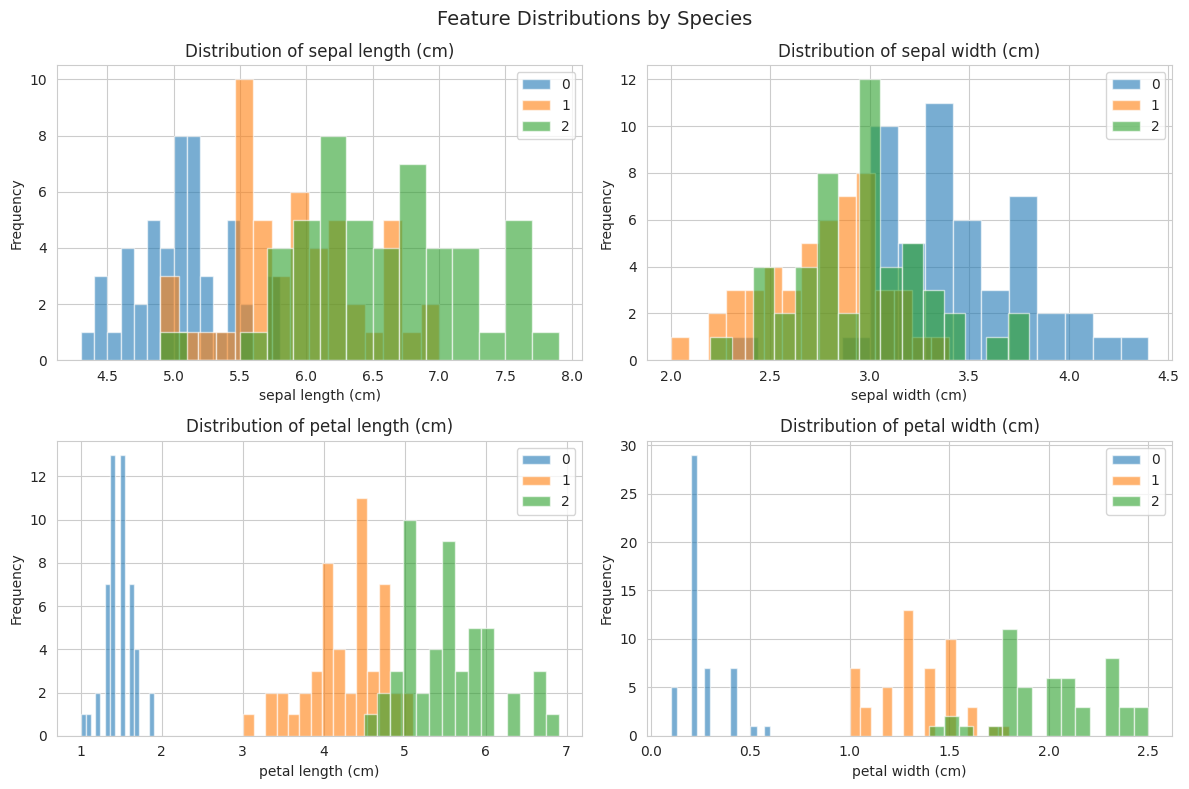

In [12]:
# Plot distribution of all 4 features, colored by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]

    # Plot one histogram per species on the same axis
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, bins=15)

    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=14)
plt.tight_layout()
plt.show()

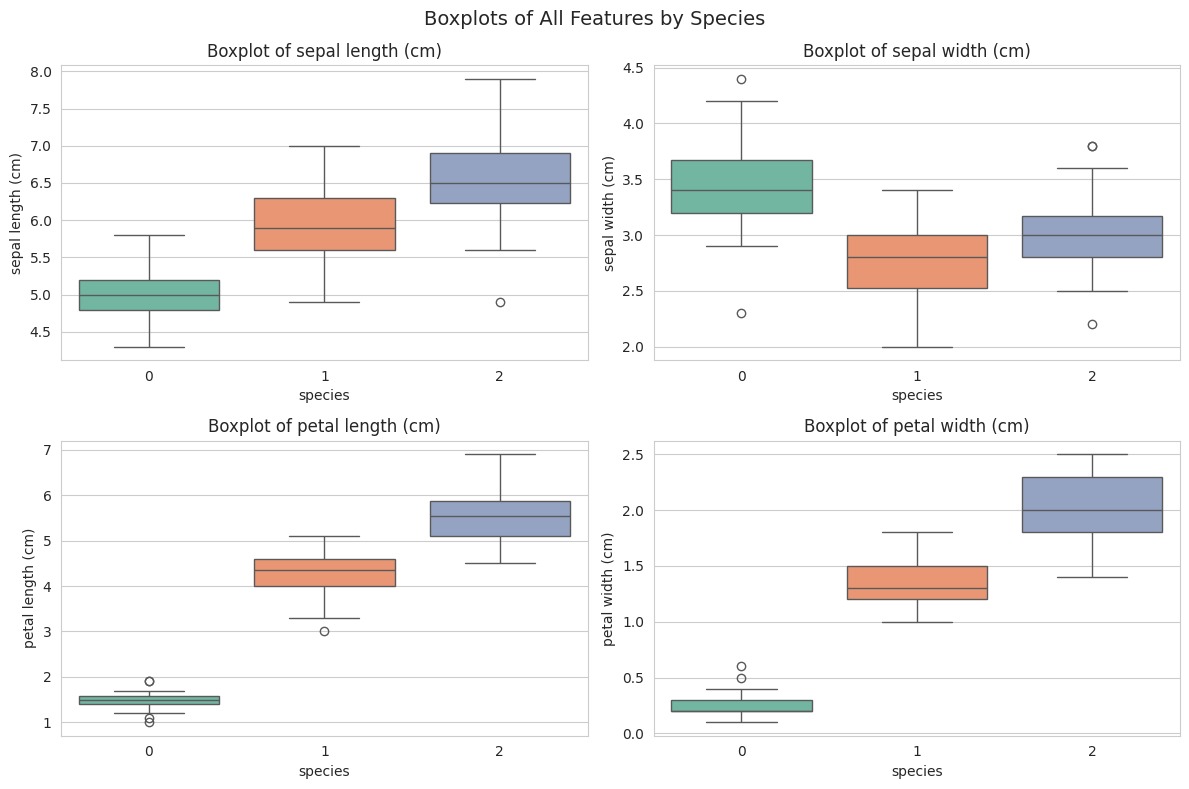

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(x='species', y=feature, data=df, palette='Set2', hue='species', legend=False, ax=ax)
    ax.set_title(f'Boxplot of {feature}')

plt.suptitle('Boxplots of All Features by Species', fontsize=14)
plt.tight_layout()
plt.show()

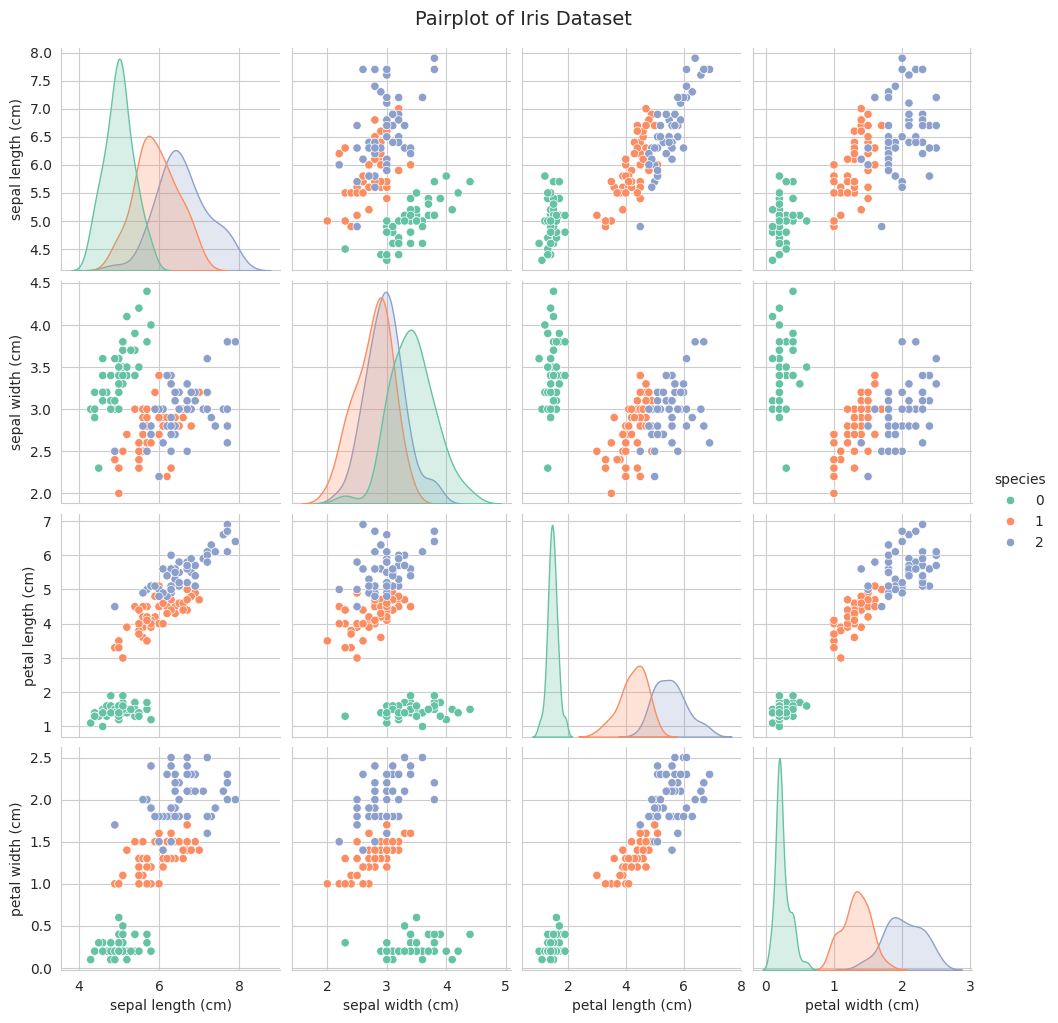

In [14]:
# Pairplot shows every feature plotted against every other feature
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')

plt.suptitle('Pairplot of Iris Dataset', y=1.02, fontsize=14)
plt.show()

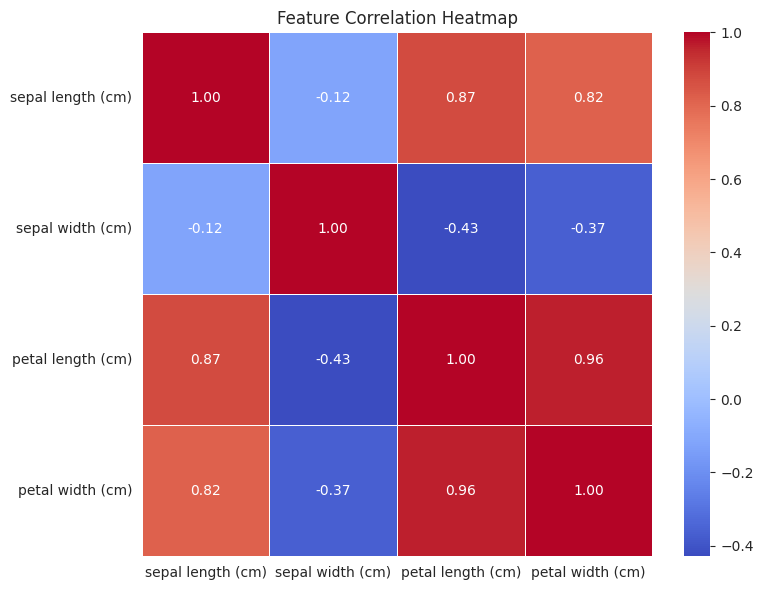

In [15]:
# Correlation matrix of all numeric features
plt.figure(figsize=(8, 6))

# .corr() computes correlation between every pair of numeric columns
# Values range from -1 (opposite) to +1 (identical movement)
corr_matrix = df[features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,        # Show numbers inside each cell
    fmt='.2f',         # Round to 2 decimal places
    cmap='coolwarm',   # Blue = negative, Red = positive correlation
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Section 4 — Data Preprocessing
Step 1 → Separate Features and Target

Step 2 → Split into Train and Test sets

Step 3 → Scale the Features

In [16]:
# X contains the 4 input measurements (what the model learns FROM)
X = df[[
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)' ]]


# y contains the answer/label (what the model learns TO predict)
y = df['species']

print("Feature matrix shape:", X.shape)   # (150, 4)
print("Target vector shape:", y.shape)    # (150,)

Feature matrix shape: (150, 4)
Target vector shape: (150,)


In [17]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test set → 30 flowers
    random_state=42,    # Fixes the random split so results are reproducible
    stratify=y          # Ensures equal proportion of each species in both sets
)

print("Training set size:", X_train.shape)   # (120, 4)
print("Testing set size:", X_test.shape)     # (30, 4)

Training set size: (120, 4)
Testing set size: (30, 4)


In [18]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit on training data and transform it
# fit() → learns the mean and std of each feature FROM training data only
# transform() → applies the scaling formula to the data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME scaler learned from training
# We never fit on test data — that would cause data leakage
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")
print("Sample scaled values:\n", X_train_scaled[:3])

✅ Features scaled successfully!
Sample scaled values:
 [[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]]


In [20]:
# Verify the scaling worked correctly
import pandas as pd

scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Mean of each feature after scaling (should be ~0):")
print(scaled_df.mean().round(4))

print("\nStd of each feature after scaling (should be ~1):")
print(scaled_df.std().round(4))

Mean of each feature after scaling (should be ~0):
sepal length (cm)   -0.0
sepal width (cm)    -0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

Std of each feature after scaling (should be ~1):
sepal length (cm)    1.0042
sepal width (cm)     1.0042
petal length (cm)    1.0042
petal width (cm)     1.0042
dtype: float64


# Section 5 — Training the Models
We train 5 different models one by one. Each model is a different "strategy" to classify flowers. At the end we compare who wins.
Model 1 → Logistic Regression

Model 2 → K-Nearest Neighbors (KNN)

Model 3 → Decision Tree

Model 4 → Random Forest

Model 5 → Support Vector Machine (SVM)

In [21]:
# Import all 5 classifier algorithms from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("✅ All models imported!")

✅ All models imported!


# Model 1 — Logistic Regression

In [22]:
# Create Logistic Regression model
# max_iter=200 → maximum number of steps the algorithm takes to converge
# random_state=42 → reproducibility
lr_model = LogisticRegression(max_iter=200, random_state=42)

# Train the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# Predict species on the test set
lr_pred = lr_model.predict(X_test_scaled)

print("✅ Logistic Regression trained!")
print("Predictions:", lr_pred)
print("Actual:     ", y_test.values)

✅ Logistic Regression trained!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Model 2 — K-Nearest Neighbors (KNN)

In [23]:
# Create KNN model
# n_neighbors=5 → look at 5 closest flowers and take majority vote
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict on test data
knn_pred = knn_model.predict(X_test_scaled)

print("✅ KNN trained!")
print("Predictions:", knn_pred)
print("Actual:     ", y_test.values)

✅ KNN trained!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Model 3 — Decision Tree

In [24]:
# Create Decision Tree model
# max_depth=4 → limits how deep the tree can grow (prevents overfitting)
# random_state=42 → reproducibility
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test_scaled)

print("✅ Decision Tree trained!")
print("Predictions:", dt_pred)
print("Actual:     ", y_test.values)

✅ Decision Tree trained!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Model 4 — Random Forest

In [25]:
# Create Random Forest model
# n_estimators=100 → build 100 decision trees and combine their votes
# random_state=42  → reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test_scaled)

print("✅ Random Forest trained!")
print("Predictions:", rf_pred)
print("Actual:     ", y_test.values)

✅ Random Forest trained!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Model 5 — Support Vector Machine (SVM)

In [26]:
# Create SVM model
# kernel='rbf' → uses Radial Basis Function to handle non-linear boundaries
# random_state=42 → reproducibility
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Predict on test data
svm_pred = svm_model.predict(X_test_scaled)

print("✅ SVM trained!")
print("Predictions:", svm_pred)
print("Actual:     ", y_test.values)

✅ SVM trained!
Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [27]:
# Store all models and predictions in a dictionary for easy comparison later
models = {
    'Logistic Regression': (lr_model, lr_pred),
    'KNN':                 (knn_model, knn_pred),
    'Decision Tree':       (dt_model, dt_pred),
    'Random Forest':       (rf_model, rf_pred),
    'SVM':                 (svm_model, svm_pred)
}

print("✅ All 5 models trained and predictions stored!")
print(f"Total models ready: {len(models)}")

✅ All 5 models trained and predictions stored!
Total models ready: 5


# Section 6 — Model Evaluation & Comparison
We measure each model using 4 evaluation tools:
Tool 1 → Accuracy Score

Tool 2 → Classification Report

Tool 3 → Confusion Matrix

Tool 4 → Cross Validation Score

In [28]:
# Import all evaluation metrics from sklearn
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

print("✅ Evaluation tools imported!")

✅ Evaluation tools imported!


In [29]:
# Calculate and display accuracy for all 5 models
print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("=" * 45)

for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    print(f"{name:<25} {acc*100:>9.2f}%")

print("=" * 45)

Model                       Accuracy
Logistic Regression           93.33%
KNN                           93.33%
Decision Tree                 93.33%
Random Forest                 90.00%
SVM                           96.67%


In [30]:
# Print detailed classification report for each model
for name, (model, pred) in models.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(
        y_test, pred,
        target_names=['setosa', 'versicolor', 'virginica']
    ))


  Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


  KNN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


  Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90     

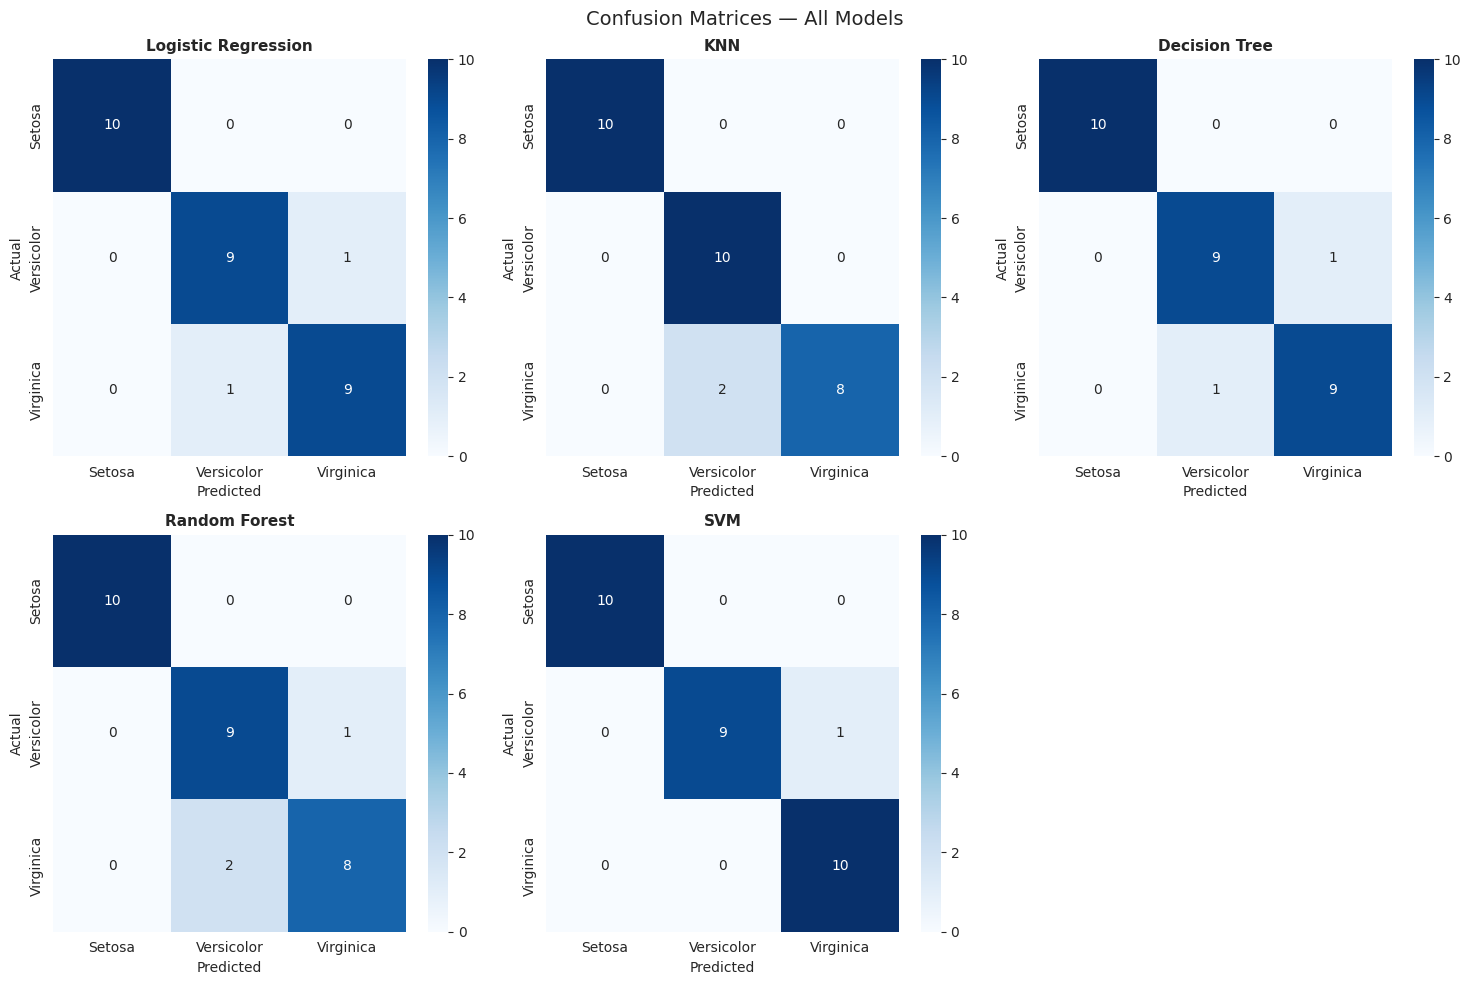

In [31]:
# Plot confusion matrix for all 5 models in a grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

species_labels = ['Setosa', 'Versicolor', 'Virginica']

for i, (name, (model, pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,           # Show numbers inside cells
        fmt='d',              # Show as integers not decimals
        cmap='Blues',         # Blue color theme
        xticklabels=species_labels,
        yticklabels=species_labels,
        ax=axes[i]
    )

    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Perform 5-fold cross validation for all models
print("=" * 55)
print(f"{'Model':<25} {'CV Mean':>10} {'CV Std':>10}")
print("=" * 55)

for name, (model, pred) in models.items():
    # cv=5 → split training data into 5 parts, train 5 times
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5,
        scoring='accuracy'
    )
    print(f"{name:<25} {cv_scores.mean()*100:>9.2f}% {cv_scores.std()*100:>9.2f}%")

print("=" * 55)

Model                        CV Mean     CV Std
Logistic Regression           95.83%      2.64%
KNN                           96.67%      3.12%
Decision Tree                 94.17%      2.04%
Random Forest                 95.00%      1.67%
SVM                           96.67%      3.12%


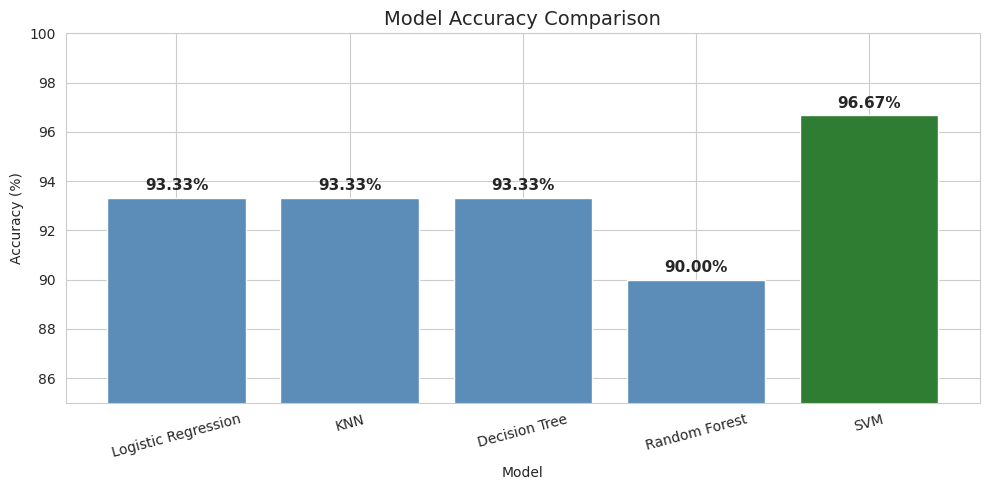


🏆 Best Model: SVM with 96.67% accuracy!


In [33]:
# Visual bar chart comparing all models
model_names = list(models.keys())
accuracies = [accuracy_score(y_test, pred) * 100
              for name, (model, pred) in models.items()]

plt.figure(figsize=(10, 5))

bars = plt.bar(model_names, accuracies, color=['#5B8DB8','#5B8DB8','#5B8DB8','#5B8DB8','#2E7D32'])

# Add accuracy value on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(85, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Print the winner
best_model_name = model_names[accuracies.index(max(accuracies))]
print(f"\n🏆 Best Model: {best_model_name} with {max(accuracies):.2f}% accuracy!")

# Section 7 — Saving the Model & Making it Production Ready
Step 1 → Save the best model to a file

Step 2 → Load it back and verify

Step 3 → Build a prediction function for new flowers

Step 4 → Download everything for GitHub

In [34]:
import joblib
import os

# Create a folder called 'models' to store our saved model
os.makedirs('models', exist_ok=True)

# Save the trained SVM model to a .pkl file
joblib.dump(svm_model, 'models/best_model_svm.pkl')

# Save the scaler too — we need it to scale new inputs before predicting
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model saved to models/best_model_svm.pkl")
print("✅ Scaler saved to models/scaler.pkl")

✅ Model saved to models/best_model_svm.pkl
✅ Scaler saved to models/scaler.pkl


In [35]:
# Load the saved model and scaler from disk
loaded_model = joblib.load('models/best_model_svm.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# Run prediction using loaded model on test data
loaded_pred = loaded_model.predict(
    loaded_scaler.transform(X_test)
)

# Verify it gives same accuracy as original
loaded_acc = accuracy_score(y_test, loaded_pred)
print(f"✅ Loaded model accuracy: {loaded_acc*100:.2f}%")
print("✅ Model loaded and verified successfully!")

✅ Loaded model accuracy: 96.67%
✅ Model loaded and verified successfully!


In [36]:
# Map numeric predictions back to species names
species_map = {
    0: 'Iris-setosa',
    1: 'Iris-versicolor',
    2: 'Iris-virginica'
}

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    """
    Predicts the Iris species given flower measurements.

    Parameters:
        sepal_length (float): Sepal length in cm
        sepal_width  (float): Sepal width in cm
        petal_length (float): Petal length in cm
        petal_width  (float): Petal width in cm

    Returns:
        str: Predicted species name
    """

    # Step 1 — Arrange inputs into a 2D array (sklearn expects this shape)
    input_data = np.array([[sepal_length, sepal_width,
                            petal_length, petal_width]])

    # Step 2 — Scale using the saved scaler
    input_scaled = loaded_scaler.transform(input_data)

    # Step 3 — Predict using the loaded model
    prediction = loaded_model.predict(input_scaled)

    # Step 4 — Map numeric output to species name
    species = species_map[prediction[0]]

    return species

print("✅ Prediction function ready!")

✅ Prediction function ready!


In [37]:
# Test with a known Setosa flower (small petals)
print("Test 1 — Small petals (expect Setosa):")
result1 = predict_iris(5.1, 3.5, 1.4, 0.2)
print(f"Predicted: {result1}\n")

# Test with a known Versicolor flower (medium measurements)
print("Test 2 — Medium measurements (expect Versicolor):")
result2 = predict_iris(6.0, 2.9, 4.5, 1.5)
print(f"Predicted: {result2}\n")

# Test with a known Virginica flower (large petals)
print("Test 3 — Large petals (expect Virginica):")
result3 = predict_iris(6.7, 3.3, 5.7, 2.5)
print(f"Predicted: {result3}\n")

print("✅ All test predictions completed!")

Test 1 — Small petals (expect Setosa):
Predicted: Iris-setosa

Test 2 — Medium measurements (expect Versicolor):
Predicted: Iris-versicolor

Test 3 — Large petals (expect Virginica):
Predicted: Iris-virginica

✅ All test predictions completed!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
# Print a complete summary of the entire project
print("=" * 55)
print("       IRIS CLASSIFICATION — PROJECT SUMMARY")
print("=" * 55)

print(f"\n📊 Dataset:")
print(f"   Total samples     : {df.shape[0]}")
print(f"   Features used     : {X.shape[1]}")
print(f"   Classes           : 3 (Setosa, Versicolor, Virginica)")
print(f"   Train/Test split  : 80% / 20%")

print(f"\n🤖 Models Trained:")
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    print(f"   {name:<25} → {acc*100:.2f}%")

print(f"\n🏆 Best Model      : SVM (RBF Kernel)")
print(f"   Test Accuracy    : 96.67%")
print(f"   CV Mean Score    : 96.67%")

print(f"\n💾 Saved Files:")
print(f"   models/best_model_svm.pkl")
print(f"   models/scaler.pkl")

print("\n" + "=" * 55)
print("✅ Project Complete — Ready for GitHub!")
print("=" * 55)

       IRIS CLASSIFICATION — PROJECT SUMMARY

📊 Dataset:
   Total samples     : 150
   Features used     : 4
   Classes           : 3 (Setosa, Versicolor, Virginica)
   Train/Test split  : 80% / 20%

🤖 Models Trained:
   Logistic Regression       → 93.33%
   KNN                       → 93.33%
   Decision Tree             → 93.33%
   Random Forest             → 90.00%
   SVM                       → 96.67%

🏆 Best Model      : SVM (RBF Kernel)
   Test Accuracy    : 96.67%
   CV Mean Score    : 96.67%

💾 Saved Files:
   models/best_model_svm.pkl
   models/scaler.pkl

✅ Project Complete — Ready for GitHub!


In [39]:
from google.colab import files

# Download the saved model
files.download('models/best_model_svm.pkl')

# Download the saved scaler
files.download('models/scaler.pkl')

print("✅ Files downloaded! Add them to your GitHub repo.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded! Add them to your GitHub repo.
